# 3. DICOM-RT I/O

Load RTDOSE and RTSTRUCT from the public example dataset. The high-level loader rasterizes contours directly on the selected dose grid, making the returned objects metric-ready.


In [1]:
from dosemetrics import Dose
from dosemetrics.io import detect_folder_format, dicom_io
from dosemetrics.metrics import dvh
from dosemetrics.utils import (
    download_example_data,
    load_dicom_ct_on_dose_grid,
    load_dicom_study,
    plot_dose_slice,
    plot_subject_dvhs,
)

dicom_dir = download_example_data("dicom")
print(f"Format: {detect_folder_format(dicom_dir)}")
for modality in ["CT", "RTDOSE", "RTSTRUCT", "RTPLAN"]:
    print(f"{modality:8s}: {len(list((dicom_dir / modality).glob('*')))} files")


Format: dicom
CT      : 107 files
RTDOSE  : 3 files
RTSTRUCT: 1 files
RTPLAN  : 3 files


## Load metric-ready containers


In [2]:
dose, structures = load_dicom_study(dicom_dir)
ptv = structures["PTV_Total"]
assert all(dose.is_compatible_with_structure(item) for _, item in structures)
print(dose)
print(f"{len(structures)} structures on the dose grid")


Dose Distribution 'RD_1':
  Shape: (107, 100, 166)
  Spacing: (2.5, 2.5, 3.0) mm
  Max dose: 72.57 Gy
  Mean dose: 1.03 Gy
  Min dose: 0.00 Gy
43 structures on the dose grid


## Display CT, dose, and RTSTRUCT contours


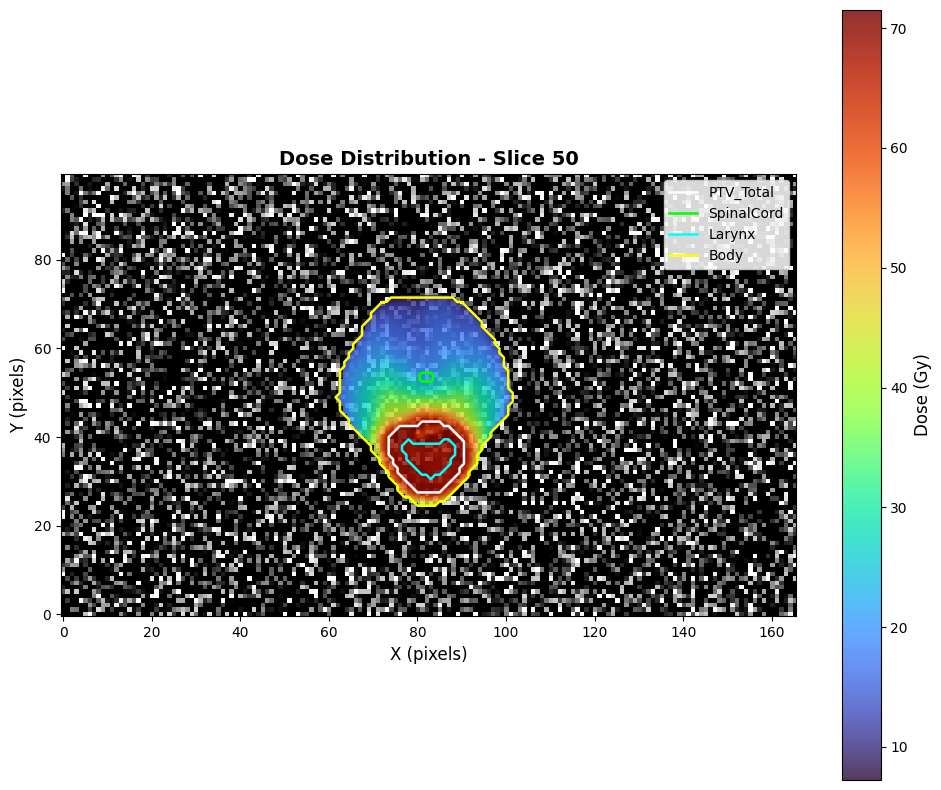

In [3]:
ct_on_dose_grid = load_dicom_ct_on_dose_grid(dicom_dir, dose)
plot_dose_slice(
    dose,
    structures=structures,
    structure_names=["PTV_Total", "SpinalCord", "Larynx", "Body"],
    contour_colors={"PTV_Total": "white", "SpinalCord": "lime", "Larynx": "cyan", "Body": "yellow"},
    background=ct_on_dose_grid,
    background_window=(-200, 250),
    cmap="turbo",
);


## Compute DICOM-backed metrics


PTV_Total DVH: 727 bins, 0.00-72.60 Gy, 0.0-100.0% volume
PTV_Total dose statistics (Gy)
  Mean    68.62
  Minimum 56.06
  Maximum 72.57
  D98     65.10
  D95     66.97
  D50     68.78
  D05     70.08
  D02     70.67


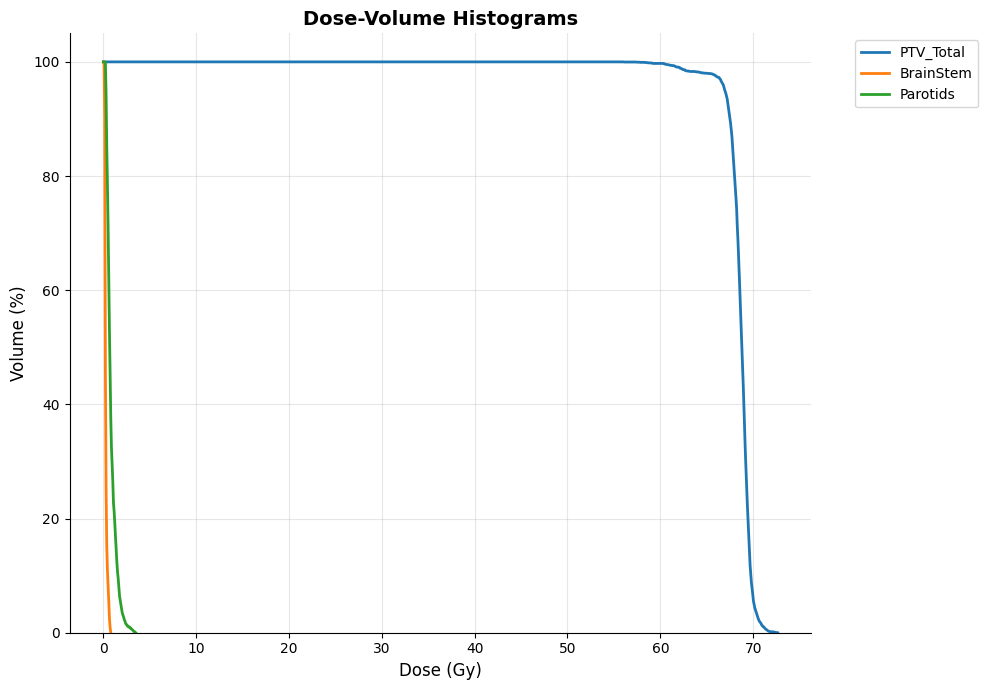

In [4]:
dose_bins, volume_percent = dvh.compute_dvh(dose, ptv, verbose=True)
statistics = dvh.compute_dose_statistics(dose, ptv, verbose=True)

plot_subject_dvhs(
    dose,
    structures,
    structure_names=["PTV_Total", "BrainStem", "Parotids"],
    color_by_type=False,
);


## Use low-level access only when needed

The folder loader exposes unwrapped arrays and DICOM metadata for specialized workflows.


In [5]:
raw = dicom_io.load_dicom_folder(dicom_dir, return_as_structureset=False)
print(sorted(raw))
print(f"Raw dose volumes: {len(raw.get('dose_volumes', {}))}")


['ct_origin', 'ct_spacing', 'ct_volume', 'dose_volumes', 'origin', 'spacing', 'structures']
Raw dose volumes: 3
